# Adversarial Perturbations in Convolutional Neural Networks: A Geometric Analysis
## Amal Abdirahman


## Setup: Imports, Hyperparameters

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Optional

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True  # full reproducibility lock
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

CLASSES = ("airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck")

BATCH_SIZE      = 64
NUM_EPOCHS      = 30
LR              = 1e-3
WD              = 1e-4

EPSILON         = 0.05
ALPHA           = EPSILON / 4   # PGD step size (
PGD_ITERS       = 40            # iterations for Plots 2-5
SWEEP_PGD_ITERS = 20            # reduced iters for Plot 1
EPSILONS        = [0.01, 0.03, 0.05, 0.07, 0.10]

# One correctly-classified image per class for Plots 2-5 and visual triplets.
# Class Indexed Selection
TARGET_CLASSES  = [0, 1, 2, 3, 4]  # airplane, automobile, bird, cat, deer

transform = transforms.Compose([transforms.ToTensor()])

full_train = datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

n_val = int(0.2 * len(full_train))
train_set, val_set = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_set):,}  Val: {len(val_set):,}  Test: {len(test_set):,}")

Running on: cuda


100%|██████████| 170M/170M [00:02<00:00, 75.3MB/s]


Train: 40,000  Val: 10,000  Test: 10,000


## Data Structures and Network Architecture

In [ ]:
@dataclass
class ExperimentConfig:
    batch_size:      int        = BATCH_SIZE
    num_epochs:      int        = NUM_EPOCHS
    learning_rate:   float      = LR
    weight_decay:    float      = WD
    epsilon_sweep:   List[float] = field(default_factory=lambda: EPSILONS)
    pgd_alpha:       float      = ALPHA
    pgd_iters:       int        = PGD_ITERS
    sweep_pgd_iters: int        = SWEEP_PGD_ITERS


@dataclass
class AttackResult:
    adversarial:           torch.Tensor
    perturbation:          torch.Tensor
    success:               bool
    gradient_norm:         Optional[float]       = None
    gradient_trajectory:   Optional[List[float]] = None
    directional_alignment: Optional[float]       = None
    linearization_error:   Optional[float]       = None

class CustomCNN(nn.Module):
    """
    VGG-style CNN for CIFAR-10 with geometric transparency.
    Three Conv->BN->ReLU->MaxPool blocks followed by a linear classifier.
    Returns raw logits (no Softmax) to preserve true gradients for adversarial
    attacks and avoid gradient masking at the output layer.

    Dimension mapping:
      R^{32x32x3} -> R^{16x16x32} -> R^{8x8x64} -> R^{4x4x128} -> R^{2048} -> R^{10}
    """
    def __init__(self) -> None:
        super().__init__()
        def block(cin: int, cout: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.net = nn.Sequential(
            block(3,  32),
            block(32, 64),
            block(64, 128),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 10))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # raw logits, Softmax applied only for display


model   = CustomCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 113,962


##  Attack Algorithms

In [ ]:
class LinearHypothesisAnalyzer:
    """
    Computes two metrics that empirically validate Goodfellow et al.'s (2015)
    linear hypothesis:

    1. Directional Alignment (Cosine Similarity): measures the geometric
       efficiency of an attack by quantifying how well the perturbation
       vector aligns with the loss gradient in R^{3072}.

    2. First-Order Linearisation Error: measures the relative error of the
       Taylor series approximation J(x+delta) ~= J(x) + delta^T * grad_J.
       A high error proves the loss manifold curves aggressively beyond the
       linear regime, justifying iterative attacks (PGD) over single-step (FGSM).
    """

    @staticmethod
    def compute_directional_alignment(
            perturbation: torch.Tensor,
            gradient:     torch.Tensor) -> float:
        """Cosine similarity between perturbation and gradient, averaged over batch."""
        flat_p = perturbation.view(perturbation.size(0), -1)
        flat_g = gradient.view(gradient.size(0), -1)
        return F.cosine_similarity(flat_p, flat_g).mean().item()

    @staticmethod
    def compute_linearization_error(
            model:        nn.Module,
            image:        torch.Tensor,
            label:        torch.Tensor,
            perturbation: torch.Tensor,
            loss_fn:      nn.Module) -> float:
        """
        Relative first-order Taylor linearisation error (Equation 9 in report):

          Error = |J(x+delta) - J(x) - delta^T * grad_J| / |J(x+delta) - J(x)|

        Uses torch.autograd.grad with create_graph=False for a clean one-off
        gradient computation that does not pollute the main computation graph.
        Designed for single-image inputs (batch_size=1); for batches, per-image
        dot products are averaged before computing the scalar error.
        """
        image_fresh = image.clone().detach().requires_grad_(True)
        model.zero_grad()
        loss_0 = loss_fn(model(image_fresh), label)
        grads  = torch.autograd.grad(loss_0, image_fresh, create_graph=False)[0]

        flat_p       = perturbation.view(perturbation.size(0), -1)
        flat_g       = grads.view(grads.size(0), -1)
        dot_products = (flat_p * flat_g).sum(dim=1)

        linear_pred = loss_0.detach() + dot_products.mean()
        with torch.no_grad():
            loss_adv = loss_fn(model(image + perturbation), label)

        denom = (loss_adv - loss_0.detach()).abs() + 1e-8
        error = (loss_adv - linear_pred).abs() / denom
        return error.mean().item()


def fgsm_attack(
        model:   nn.Module,
        image:   torch.Tensor,
        label:   torch.Tensor,
        epsilon: float,
        loss_fn: nn.Module) -> AttackResult:
    """
    Fast Gradient Sign Method (Goodfellow et al., 2015).
    Single-step L-inf attack: x_adv = x + epsilon * sign(grad_x J).

    [F4] model.eval() called defensively at entry to protect BatchNorm running
    statistics regardless of caller context.
    """
    model.eval()
    img_opt = image.clone().detach().requires_grad_(True)
    model.zero_grad()
    loss_fn(model(img_opt), label).backward()

    grad        = img_opt.grad.data
    perturbation = epsilon * grad.sign()
    adversarial  = torch.clamp(img_opt.detach() + perturbation, 0.0, 1.0)

    alignment = LinearHypothesisAnalyzer.compute_directional_alignment(perturbation, grad)
    lin_error = LinearHypothesisAnalyzer.compute_linearization_error(
        model, image, label, perturbation, loss_fn)

    with torch.no_grad():
        success = (model(adversarial).argmax(dim=1) != label).any().item()

    return AttackResult(
        adversarial           = adversarial,
        perturbation          = perturbation,
        success               = success,
        gradient_norm         = grad.view(grad.size(0), -1).norm(p=2, dim=1).mean().item(),
        directional_alignment = alignment,
        linearization_error   = lin_error)


def pgd_attack(
        model:   nn.Module,
        image:   torch.Tensor,
        label:   torch.Tensor,
        epsilon: float,
        alpha:   float,
        iters:   int) -> Tuple[AttackResult, List[float]]:
    """
    Projected Gradient Descent (Madry et al., 2018).
    Random L-inf init -> iterative sign-gradient ascent -> L-inf projection.

    x^{(0)}   = x + U(-epsilon, epsilon)        [random init inside epsilon-ball]
    x^{(t+1)} = Pi_{B_eps(x)} (x^{(t)} + alpha * sign(grad_x J))  [projected step]

    Returns (AttackResult, list of per-iteration L2 gradient norms).

    [F1] CrossEntropyLoss uses default reduction='mean'.
         sign() is scale-invariant so attack direction is unchanged, but
         grad_norms are now batch-size-invariant and directly comparable
         to the single-image norms reported for Plot 2 and in telemetry.
    """
    model.eval()
    loss_fn    = nn.CrossEntropyLoss()
    batch_size = image.size(0)

    x_adv      = (image.clone().detach()
                  + torch.empty_like(image).uniform_(-epsilon, epsilon)).clamp(0.0, 1.0)
    grad_norms = []

    for _ in range(iters):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        model.zero_grad()
        loss_fn(model(x_adv), label).backward()

        g = x_adv.grad.data
        grad_norms.append(g.view(batch_size, -1).norm(p=2, dim=1).mean().item())

        with torch.no_grad():
            delta = torch.clamp(x_adv + alpha * g.sign() - image, -epsilon, epsilon)
            x_adv = torch.clamp(image + delta, 0.0, 1.0)

    perturbation = (x_adv - image).detach()
    alignment    = LinearHypothesisAnalyzer.compute_directional_alignment(perturbation, g)
    lin_error    = LinearHypothesisAnalyzer.compute_linearization_error(
        model, image, label, perturbation, nn.CrossEntropyLoss())

    with torch.no_grad():
        success = (model(x_adv).argmax(dim=1) != label).any().item()

    result = AttackResult(
        adversarial           = x_adv.detach(),
        perturbation          = perturbation,
        success               = success,
        gradient_norm         = grad_norms[-1],
        gradient_trajectory   = grad_norms,
        directional_alignment = alignment,
        linearization_error   = lin_error)
    return result, grad_norms

## Training

In [ ]:
class AdversarialExperiment:

    def __init__(self, config: ExperimentConfig, model: nn.Module) -> None:
        self.config    = config
        self.device    = DEVICE
        self.model     = model.to(self.device)
        self.loss_fn   = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate, weight_decay=config.weight_decay)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=10, gamma=0.1)
        self.history: Dict[str, List[float]] = {'train_loss': [], 'val_loss': []}

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> None:
        print(f"Training for {self.config.num_epochs} epochs...")
        for epoch in range(1, self.config.num_epochs + 1):

            # Train phase
            self.model.train()
            train_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad(set_to_none=True)
                loss = self.loss_fn(self.model(images), labels)
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item() * images.size(0)

            # Validation phase
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    val_loss += self.loss_fn(self.model(images), labels).item() * images.size(0)

            # Capture LR used this epoch BEFORE scheduler.step() advances it
            current_lr = self.scheduler.get_last_lr()[0]
            self.scheduler.step()
            self.history['train_loss'].append(train_loss / len(train_loader.dataset))
            self.history['val_loss'].append(val_loss   / len(val_loader.dataset))

            if epoch % 5 == 0:
                print(f"Epoch {epoch:3d}/{self.config.num_epochs}  "
                      f"Train: {self.history['train_loss'][-1]:.4f}  "
                      f"Val: {self.history['val_loss'][-1]:.4f}  "
                      f"LR: {current_lr:.1e}")

    def evaluate_clean_accuracy(self, loader: DataLoader) -> float:
        self.model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                correct += (self.model(images).argmax(dim=1) == labels).sum().item()
                total   += labels.size(0)
        accuracy = 100.0 * correct / total
        print(f"Clean Test Accuracy: {accuracy:.2f}%")
        return accuracy

    def evaluate_attack_accuracy(
            self, loader: DataLoader,
            attack_type: str,
            epsilon: float,
            **kwargs) -> float:
        """
        Accuracy (%) of model under FGSM or PGD attack over a full loader.
        Two separate passes per epsilon value — one per attack mode.
        """
        self.model.eval()
        correct, total = 0, 0
        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)
            if attack_type == 'fgsm':
                result     = fgsm_attack(self.model, images, labels, epsilon, self.loss_fn)
                adv_images = result.adversarial
            else:
                result, _  = pgd_attack(self.model, images, labels, epsilon,
                                        kwargs.get('alpha', epsilon / 4),
                                        kwargs.get('iters', self.config.pgd_iters))
                adv_images = result.adversarial
            with torch.no_grad():
                correct += (self.model(adv_images).argmax(dim=1) == labels).sum().item()
                total   += labels.size(0)
        return 100.0 * correct / total

    def run_epsilon_sweep(self, loader: DataLoader) -> Dict[str, List[float]]:
        print(f"\nRunning epsilon sweep on full test set ({len(loader.dataset):,} images)...")
        sweep_results: Dict[str, List[float]] = {'fgsm': [], 'pgd': []}
        for eps in self.config.epsilon_sweep:
            fgsm_acc = self.evaluate_attack_accuracy(loader, 'fgsm', eps)
            pgd_acc  = self.evaluate_attack_accuracy(
                loader, 'pgd', eps,
                alpha=eps / 4, iters=self.config.sweep_pgd_iters)
            sweep_results['fgsm'].append(fgsm_acc)
            sweep_results['pgd'].append(pgd_acc)
            print(f"  ε={eps:.2f}  FGSM={fgsm_acc:.1f}%  "
                  f"PGD({self.config.sweep_pgd_iters} steps)={pgd_acc:.1f}%")
        return sweep_results

    def plot_accuracy_vs_epsilon(
            self,
            sweep_results: Dict[str, List[float]],
            clean_accuracy: float) -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(self.config.epsilon_sweep, sweep_results['fgsm'],
                'o-', linewidth=2.5, color='steelblue', label='FGSM (1-step)')
        ax.plot(self.config.epsilon_sweep, sweep_results['pgd'],
                's--', linewidth=2.5, color='crimson',
                label=f"PGD ({self.config.sweep_pgd_iters} steps)")
        ax.axhline(clean_accuracy, color='gray', linestyle=':', linewidth=1.5,
                   label=f'Clean ({clean_accuracy:.1f}%)')
        ax.set_xlabel(r'Perturbation Budget $\epsilon$ (L$_\infty$ norm)', fontsize=12)
        ax.set_ylabel('Test Accuracy (%)', fontsize=12)
        ax.set_title('Plot 1: Accuracy vs ε — FGSM and PGD Attacks',
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-5, 105)
        plt.tight_layout()
        plt.savefig("plot1_epsilon_sweep.png", dpi=150)
        plt.show()

    def plot_gradient_trajectory(
            self, grad_norms: List[float], class_name: str) -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(range(1, len(grad_norms) + 1), grad_norms,
                color='crimson', linewidth=2, marker='.', markersize=6)
        ax.set_xlabel(r'PGD Iteration $k$', fontsize=12)
        ax.set_ylabel(r'$\|\nabla_x J\|_2$', fontsize=12)
        ax.set_title(f'Plot 2: L2 Gradient Norm over PGD Iterations [{class_name}]',
                     fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("plot2_grad_norms.png", dpi=150)
        plt.show()

    def plot_loss_slice(
            self,
            image:        torch.Tensor,
            label:        torch.Tensor,
            perturbation: torch.Tensor) -> None:
        """
        Plot 3: 1D Loss Slice — J(x + alpha*g) vs J(x + alpha*v).

        [F2] Accepts the pre-computed PGD perturbation tensor directly rather
        than running a second independent pgd_attack internally. This guarantees
        that the geometric direction g used here is from the same attack
        trajectory as the telemetry values printed at the end of the script.

        No [0,1] clamping on the interpolated inputs: this is a pure geometric
        loss-surface probe. Clamping would artificially flatten the curve at
        pixel boundaries and misrepresent the true loss landscape curvature.
        Adversarial images generated for accuracy evaluation always apply the clamp.
        """
        g = perturbation.squeeze(0)
        v = torch.randn_like(g)
        v = v * (g.norm(p=2) / (v.norm(p=2) + 1e-12))

        alphas   = np.linspace(0.0, 1.0, 80)
        losses_g, losses_v = [], []

        self.model.eval()
        with torch.no_grad():
            for a in alphas:
                a_t = torch.tensor(a, dtype=torch.float32, device=self.device)
                losses_g.append(
                    self.loss_fn(self.model((image + a_t * g).unsqueeze(0)),
                                 label.unsqueeze(0)).item())
                losses_v.append(
                    self.loss_fn(self.model((image + a_t * v).unsqueeze(0)),
                                 label.unsqueeze(0)).item())

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(alphas, losses_g, linewidth=2.5, color='crimson',
                label=r'Adversarial vector $\mathbf{g}$')
        ax.plot(alphas, losses_v, linewidth=2.5, color='steelblue', linestyle='--',
                label=r'Random vector $\mathbf{v}$ (same L$_2$ norm)')
        ax.axvline(1.0, color='gray', linestyle=':', linewidth=1,
                   label=r'$\alpha=1 \Rightarrow J(\mathbf{x}_{adv})$')
        ax.set_xlabel(r'Interpolation parameter $\alpha$', fontsize=12)
        ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
        ax.set_title(
            r'Plot 3: 1D Loss Slice $J(\mathbf{x}+\alpha\mathbf{g})$ vs'
            r' $J(\mathbf{x}+\alpha\mathbf{v})$',
            fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', framealpha=0.9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("plot3_loss_slice.png", dpi=150)
        plt.show()

    def plot_training_curves(self) -> None:
        epochs = range(1, len(self.history['train_loss']) + 1)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(epochs, self.history['train_loss'],
                linewidth=2, label='Train Loss', color='steelblue')
        ax.plot(epochs, self.history['val_loss'],
                linewidth=2, label='Val Loss', color='darkorange', linestyle='--')
        for drop_epoch in [10, 20]:
            ax.axvline(drop_epoch, color='green', linestyle=':', linewidth=1.2,
                       alpha=0.7, label='LR drop' if drop_epoch == 10 else None)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
        ax.set_title('Plot 4: Training vs Validation Loss  '
                     '(StepLR drops at epochs 10 & 20)',
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', framealpha=0.9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("plot4_training_curve.png", dpi=150)
        plt.show()

    def plot_visual_triplets(
            self,
            samples: List[Tuple[torch.Tensor, torch.Tensor]],
            epsilon: float) -> None:
        n = len(samples)
        fig, axes = plt.subplots(n, 3, figsize=(10, 3.5 * n))
        fig.suptitle(f'Plot 5: Visual Triplets — PGD Attack (ε = {epsilon})',
                     fontsize=14, fontweight='bold')
        for ax, title in zip(axes[0],
                             ['Original', 'Perturbation\n(magnified)', 'Adversarial']):
            ax.set_title(title, fontsize=11, fontweight='bold')

        for row, (orig, lbl) in enumerate(samples):
            result, _ = pgd_attack(self.model, orig, lbl, epsilon, epsilon / 4, PGD_ITERS)
            adv = result.adversarial

            with torch.no_grad():
                orig_pred = self.model(orig).argmax(dim=1)
                orig_conf = F.softmax(self.model(orig), dim=1).max().item() * 100
                adv_pred  = self.model(adv).argmax(dim=1)
                adv_conf  = F.softmax(self.model(adv),  dim=1).max().item() * 100

            delta     = adv - orig
            delta_vis = ((delta - delta.min()) /
                         (delta.max() - delta.min() + 1e-12)).clamp(0, 1)

            axes[row, 0].imshow(self._tensor_to_numpy(orig))
            axes[row, 0].set_xlabel(
                f"True: {CLASSES[lbl.item()]}\n"
                f"Pred: {CLASSES[orig_pred.item()]} ({orig_conf:.1f}%)", fontsize=8)

            axes[row, 1].imshow(self._tensor_to_numpy(delta_vis))
            axes[row, 1].set_xlabel(
                r"$\delta = \mathbf{x}_{adv} - \mathbf{x}$" + "\n(min-max scaled)",
                fontsize=8)

            colour = 'red' if adv_pred != lbl else 'green'
            axes[row, 2].imshow(self._tensor_to_numpy(adv))
            axes[row, 2].set_xlabel(
                f"Pred: {CLASSES[adv_pred.item()]} ({adv_conf:.1f}%)",
                fontsize=8, color=colour)

            for ax in axes[row]:
                ax.set_xticks([]); ax.set_yticks([])

        plt.tight_layout()
        plt.savefig("plot5_triplets.png", dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def _tensor_to_numpy(tensor: torch.Tensor) -> np.ndarray:
        """(1,C,H,W) or (C,H,W) tensor -> (H,W,C) float32 array in [0,1]."""
        return tensor.squeeze(0).permute(1, 2, 0).clamp(0, 1).cpu().numpy()

##  Sample Selection

In [ ]:
def get_one_correct_per_class(
        model:          nn.Module,
        loader:         DataLoader,
        target_classes: List[int],
        device:         torch.device) -> List[Tuple[torch.Tensor, torch.Tensor]]:
    """
    Returns one correctly-classified (image, label) pair per class in target_classes.
    Iterates the loader once; class-indexed dictionary guarantees diversity.

    Without this, sequential iteration over an unshuffled CIFAR-10 test set
    always returns the same image on every run (the first correctly-classified
    image encountered — which happens to be a cat at seed 42).
    """
    model.eval()
    found: Dict[int, Tuple[torch.Tensor, torch.Tensor]] = {}
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            for i in range(images.size(0)):
                c = labels[i].item()
                if c in target_classes and c not in found and preds[i] == labels[i]:
                    found[c] = (images[i:i+1], labels[i:i+1])
                if len(found) == len(target_classes):
                    return [found[c] for c in target_classes]
    return [found[c] for c in target_classes if c in found]

## Execution

Training for 30 epochs...
Epoch   5/30  Train: 0.5630  Val: 0.9862  LR: 1.0e-03
Epoch  10/30  Train: 0.2737  Val: 0.8437  LR: 1.0e-03
Epoch  15/30  Train: 0.0908  Val: 0.6833  LR: 1.0e-04
Epoch  20/30  Train: 0.0602  Val: 0.7162  LR: 1.0e-04
Epoch  25/30  Train: 0.0470  Val: 0.7256  LR: 1.0e-05
Epoch  30/30  Train: 0.0442  Val: 0.7352  LR: 1.0e-05
Clean Test Accuracy: 78.50%

Running epsilon sweep on full test set (10,000 images)...
  ε=0.01  FGSM=5.8%  PGD(20 steps)=1.0%
  ε=0.03  FGSM=0.6%  PGD(20 steps)=0.0%
  ε=0.05  FGSM=0.3%  PGD(20 steps)=0.0%
  ε=0.07  FGSM=0.3%  PGD(20 steps)=0.0%
  ε=0.10  FGSM=0.6%  PGD(20 steps)=0.0%


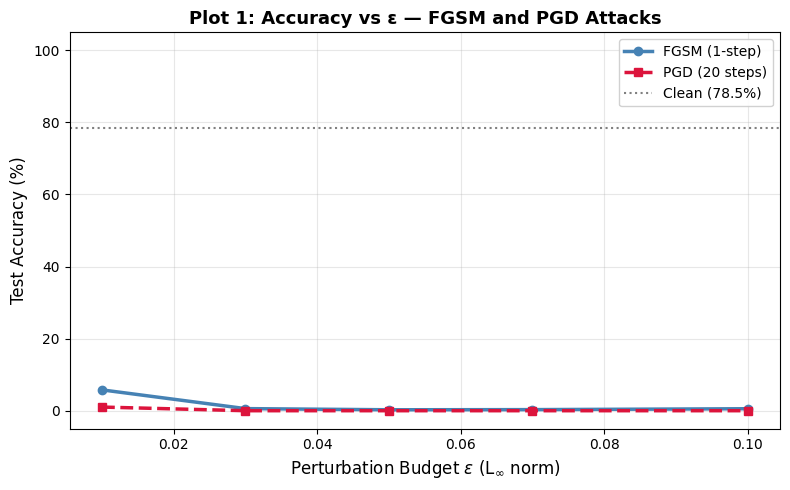


Geometric plot sample : airplane
Triplet classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer']


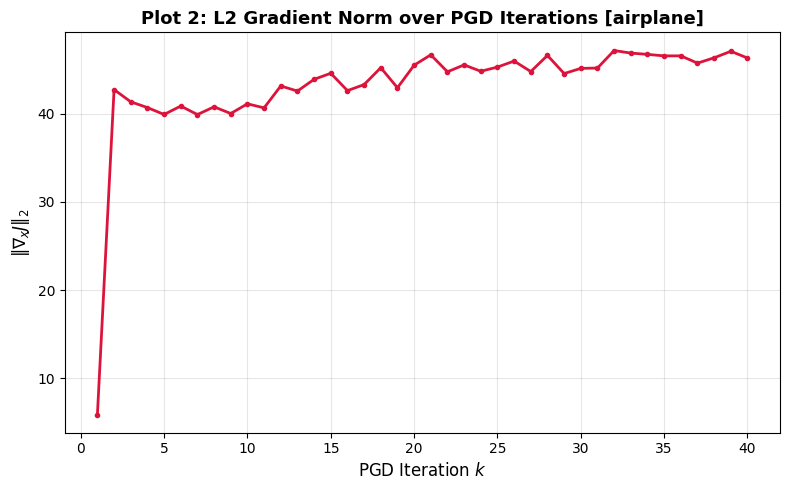

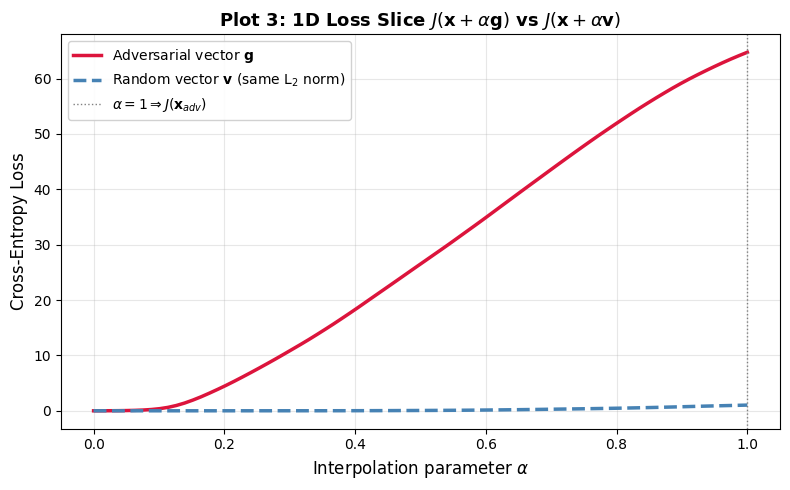

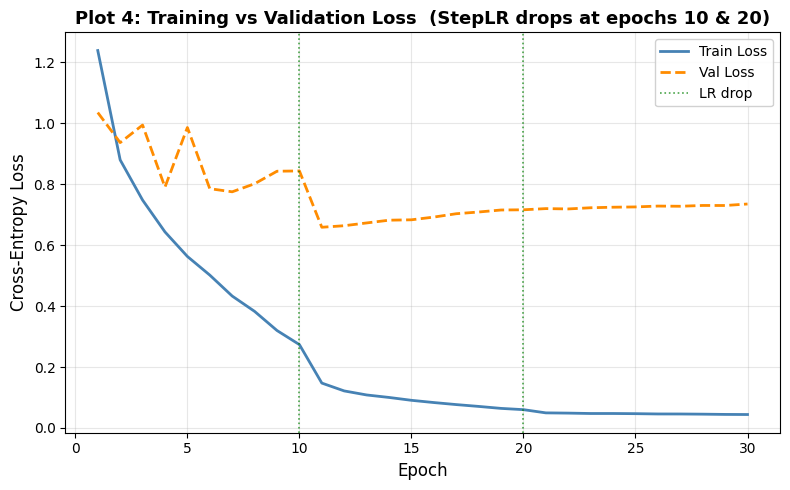

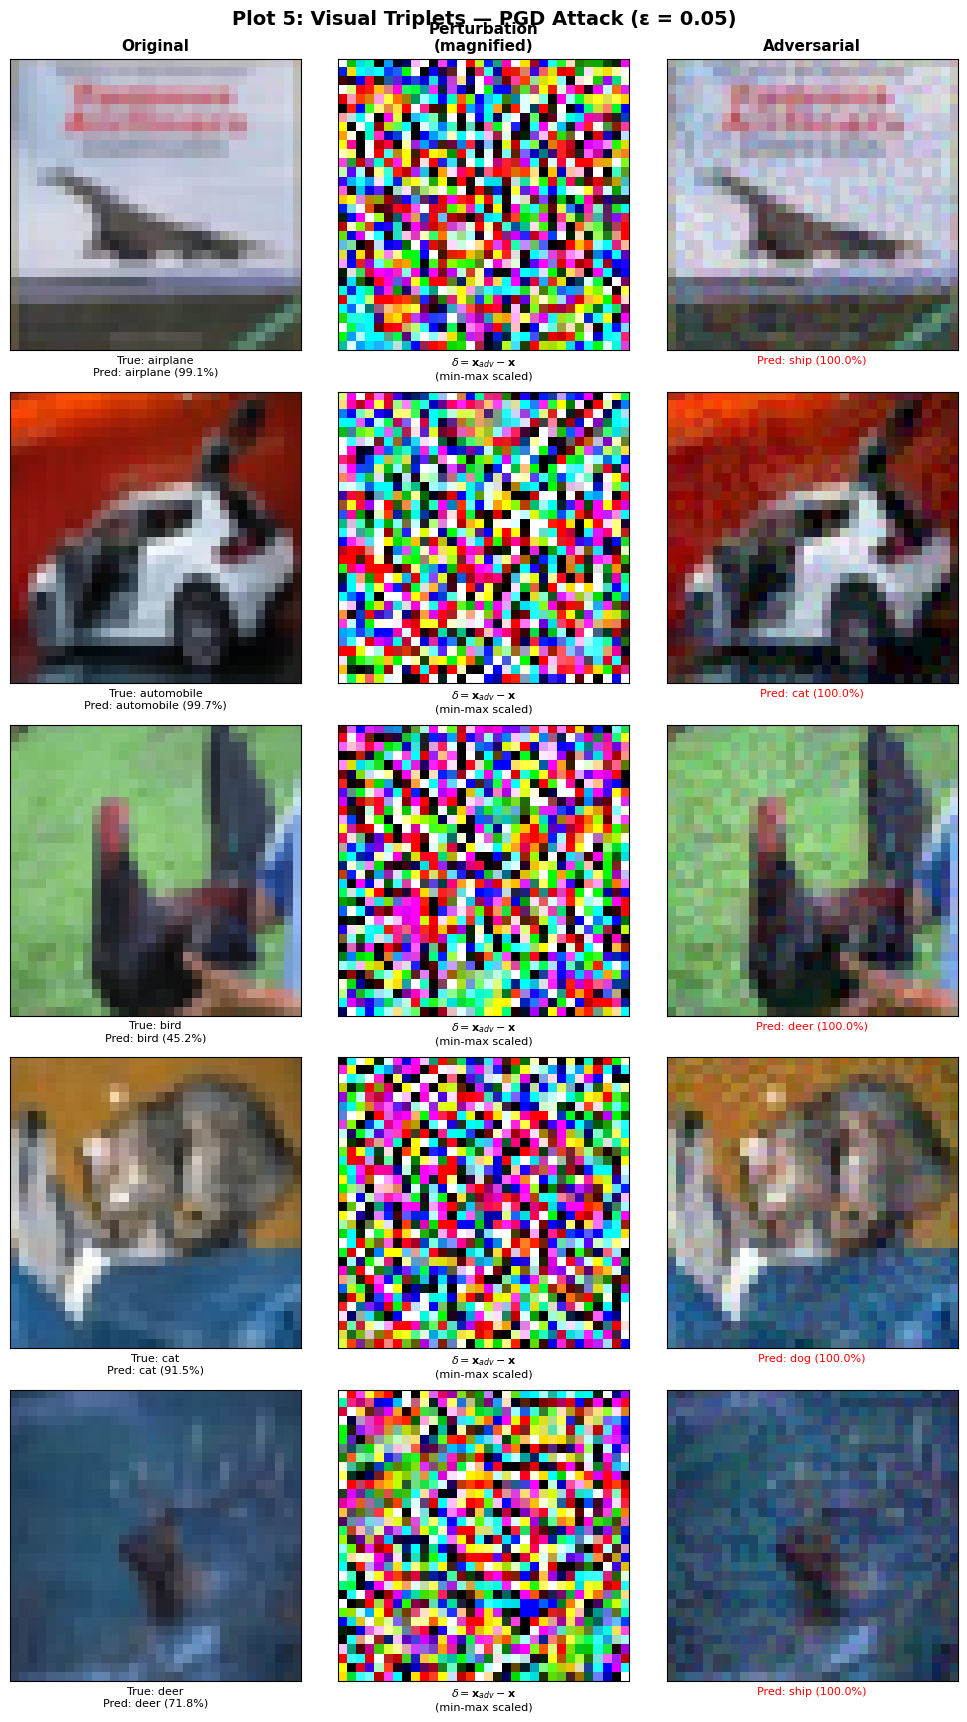


Statistics for Geometic Analysis
Sample Class                                : airplane
FGSM directional alignment (cosine sim)     : 0.7451
FGSM linearisation error (Taylor approx)    : 0.9597
PGD  directional alignment (final step)     : 0.5737
PGD  linearisation error (final step)       : 0.9956
PGD  final gradient L2 norm                 : 46.3030


In [ ]:
# Initialise
config     = ExperimentConfig()
experiment = AdversarialExperiment(config, model)

# Train
experiment.train(train_loader, val_loader)

# Clean baseline
clean_acc = experiment.evaluate_clean_accuracy(test_loader)

# Plot 1 — full 10,000-image epsilon sweep
sweep_results = experiment.run_epsilon_sweep(test_loader)
experiment.plot_accuracy_vs_epsilon(sweep_results, clean_acc)

# Diverse sample selection for geometric plots
plot_samples = get_one_correct_per_class(
    experiment.model, test_loader, TARGET_CLASSES, DEVICE)
sample_image, sample_label = plot_samples[0]
print(f"\nGeometric plot sample : {CLASSES[sample_label.item()]}")
print(f"Triplet classes       : {[CLASSES[p[1].item()] for p in plot_samples]}")

# Definitive single-image attacks — run ONCE, results shared across all plots
# [F3] pgd_result.perturbation passed directly to plot_loss_slice so that
#      Plot 3's geometric direction g is from the same trajectory as the
#      telemetry values printed below. Previously a second pgd_attack was
#      called inside plot_loss_slice with a different random initialisation.
fgsm_result              = fgsm_attack(
    experiment.model, sample_image, sample_label, EPSILON, experiment.loss_fn)
pgd_result, pgd_trajectory = pgd_attack(
    experiment.model, sample_image, sample_label, EPSILON, ALPHA, PGD_ITERS)

# Plot 2 — gradient norm trajectory
experiment.plot_gradient_trajectory(pgd_trajectory, CLASSES[sample_label.item()])

# Plot 3 — 1D loss slice using pre-computed perturbation [F2, F3]
experiment.plot_loss_slice(
    image        = sample_image.squeeze(0),
    label        = sample_label.squeeze(0),
    perturbation = pgd_result.perturbation)

# Plot 4 — training curve
experiment.plot_training_curves()

# Plot 5 — visual triplets
experiment.plot_visual_triplets(plot_samples, EPSILON)


print("\n" + "=" * 60)
print("Statistics for Geometic Analysis")
print("=" * 60)
print(f"Sample Class                                : {CLASSES[sample_label.item()]}")
print(f"FGSM directional alignment (cosine sim)     : {fgsm_result.directional_alignment:.4f}")
print(f"FGSM linearisation error (Taylor approx)    : {fgsm_result.linearization_error:.4f}")
print(f"PGD  directional alignment (final step)     : {pgd_result.directional_alignment:.4f}")
print(f"PGD  linearisation error (final step)       : {pgd_result.linearization_error:.4f}")
print(f"PGD  final gradient L2 norm                 : {pgd_result.gradient_norm:.4f}")
print("=" * 60)